# Markov Switching Models for Time Series

## What is a Markov Switching Model?

A **Markov Switching Model (MSM)** is a regression model where the parameters (intercept, slope, variance) switch between discrete **regimes** according to a hidden Markov chain. It was popularized by James Hamilton (1989) for modeling business cycles.

## The Model

$$y_t = \alpha_{s_t} + \beta_{s_t} x_t + \varepsilon_t, \quad \varepsilon_t \sim N(0, \sigma_{s_t}^2)$$

where $s_t \in \{0, 1, ..., K-1\}$ is the unobserved regime at time $t$, evolving as:

$$P(s_t = j \mid s_{t-1} = i) = a_{ij}$$

## Why Use MSM?

| Feature | Standard Regression | Markov Switching |
|---------|--------------------|------------------|
| Parameters | Fixed | Regime-dependent |
| Variance | Homoscedastic | Heteroscedastic by regime |
| Structural breaks | Manual dummies | Endogenously detected |
| Interpretation | Average effect | Regime-specific effects |

## Key Algorithms

| Algorithm | Purpose |
|-----------|---------|
| **Hamilton Filter** | Forward pass: $P(s_t \mid y_{1:t})$ |
| **Kim Smoother** | Backward pass: $P(s_t \mid y_{1:T})$ |
| **Viterbi** | Most likely state sequence |
| **Baum-Welch EM** | Maximum Likelihood estimation |


In [62]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

# ============================================
# Generate Synthetic Markov Switching Data
# ============================================
# Model: y_t = alpha_{s_t} + beta_{s_t} * x_t + epsilon_t

T = 400
n_regimes = 2

# True transition matrix
transition_true = np.array([[0.95, 0.05],
                            [0.08, 0.92]])

# True parameters per regime
alpha_true = np.array([1.0, -1.5])
beta_true = np.array([0.5, 2.0])
sigma_true = np.array([0.8, 1.8])

# Exogenous variable x_t (AR(1) process)
x = np.zeros(T)
x[0] = np.random.normal(0, 1)
for t in range(1, T):
    x[t] = 0.7 * x[t-1] + np.random.normal(0, 1)
x = (x - x.mean()) / x.std()

# Generate state sequence
states_true = np.zeros(T, dtype=int)
states_true[0] = 0
for t in range(1, T):
    states_true[t] = np.random.choice(n_regimes, p=transition_true[states_true[t-1]])

# Generate observations
y = np.zeros(T)
for t in range(T):
    y[t] = (alpha_true[states_true[t]] + 
            beta_true[states_true[t]] * x[t] + 
            np.random.normal(0, sigma_true[states_true[t]]))

time = np.arange(T)

print("Data generated!")
print(f"Observations: {T}")
print(f"Regime 0: {(states_true == 0).sum()} periods")
print(f"Regime 1: {(states_true == 1).sum()} periods")


Data generated!
Observations: 400
Regime 0: 297 periods
Regime 1: 103 periods


In [63]:
# ============================================
# Markov Switching Regression (from scratch)
# ============================================

class MarkovSwitchingRegression:
    def __init__(self, n_regimes=2):
        self.n_regimes = n_regimes
        self.pi = None
        self.A = None
        self.alphas = None
        self.betas = None
        self.sigmas = None
        
    def _emission_prob(self, y, x, alphas, betas, sigmas):
        T = len(y)
        probs = np.zeros((T, self.n_regimes))
        for k in range(self.n_regimes):
            resid = y - (alphas[k] + betas[k] * x)
            probs[:, k] = stats.norm.pdf(resid, 0, sigmas[k])
        return probs
    
    def forward(self, y, x, pi, A, alphas, betas, sigmas):
        T = len(y)
        alpha_fwd = np.zeros((T, self.n_regimes))
        c = np.zeros(T)
        B = self._emission_prob(y, x, alphas, betas, sigmas)
        
        alpha_fwd[0] = pi * B[0]
        c[0] = alpha_fwd[0].sum()
        alpha_fwd[0] /= c[0]
        
        for t in range(1, T):
            for j in range(self.n_regimes):
                alpha_fwd[t, j] = B[t, j] * np.sum(alpha_fwd[t-1] * A[:, j])
            c[t] = alpha_fwd[t].sum()
            alpha_fwd[t] /= c[t]
        
        return alpha_fwd, c
    
    def backward(self, y, x, A, alphas, betas, sigmas, c):
        T = len(y)
        beta_bwd = np.zeros((T, self.n_regimes))
        beta_bwd[-1] = 1.0 / c[-1]
        
        for t in range(T-2, -1, -1):
            B_next = self._emission_prob(y[t+1:t+2], x[t+1:t+2], alphas, betas, sigmas)[0]
            for i in range(self.n_regimes):
                beta_bwd[t, i] = np.sum(A[i, :] * B_next * beta_bwd[t+1]) / c[t]
        
        return beta_bwd
    
    def forward_backward(self, y, x, pi, A, alphas, betas, sigmas):
        alpha_fwd, c = self.forward(y, x, pi, A, alphas, betas, sigmas)
        beta_bwd = self.backward(y, x, A, alphas, betas, sigmas, c)
        
        T = len(y)
        gamma = np.zeros((T, self.n_regimes))
        xi = np.zeros((T-1, self.n_regimes, self.n_regimes))
        
        for t in range(T):
            denom = np.sum(alpha_fwd[t] * beta_bwd[t])
            if denom == 0:
                denom = 1e-10
            gamma[t] = (alpha_fwd[t] * beta_bwd[t]) / denom
        
        B = self._emission_prob(y, x, alphas, betas, sigmas)
        for t in range(T-1):
            for i in range(self.n_regimes):
                for j in range(self.n_regimes):
                    xi[t, i, j] = (alpha_fwd[t, i] * A[i, j] * 
                                     B[t+1, j] * beta_bwd[t+1, j])
            denom = xi[t].sum()
            if denom == 0:
                denom = 1e-10
            xi[t] /= denom
        
        return gamma, xi, c
    
    def em(self, y, x, n_iter=150, tol=1e-6):
        T = len(y)
        
        # Initialize
        median_y = np.median(y)
        mask0 = y >= median_y
        mask1 = y < median_y
        
        self.pi = np.array([0.6, 0.4])
        self.A = np.array([[0.9, 0.1], [0.1, 0.9]])
        
        Xd = np.column_stack([np.ones(T), x])
        
        def wls(y, X, w):
            W = np.diag(w)
            XtWX = X.T @ W @ X
            if np.linalg.cond(XtWX) > 1e12:
                XtWX += np.eye(X.shape[1]) * 1e-6
            return np.linalg.inv(XtWX) @ (X.T @ W @ y)
        
        w0 = np.ones(T) * 0.5
        w0[mask0] = 0.9
        w0[mask1] = 0.1
        w1 = 1 - w0
        
        b0 = wls(y, Xd, w0)
        b1 = wls(y, Xd, w1)
        
        self.alphas = np.array([b0[0], b1[0]])
        self.betas = np.array([b0[1], b1[1]])
        
        r0 = y - (self.alphas[0] + self.betas[0] * x)
        r1 = y - (self.alphas[1] + self.betas[1] * x)
        self.sigmas = np.array([
            np.sqrt(np.sum(w0 * r0**2) / np.sum(w0)),
            np.sqrt(np.sum(w1 * r1**2) / np.sum(w1))
        ])
        self.sigmas = np.clip(self.sigmas, 1e-6, None)
        
        log_likes = []
        
        for it in range(n_iter):
            gamma, xi, c = self.forward_backward(y, x, self.pi, self.A, 
                                                  self.alphas, self.betas, self.sigmas)
            
            ll = np.sum(np.log(c + 1e-300))
            log_likes.append(ll)
            
            if it > 0 and abs(log_likes[-1] - log_likes[-2]) < tol:
                break
            
            # Update transition matrix
            self.pi = gamma[0]
            self.A = xi.sum(axis=0) / (gamma[:-1].sum(axis=0)[:, None] + 1e-10)
            self.A = np.clip(self.A, 0.01, 0.99)
            self.A /= self.A.sum(axis=1, keepdims=True)
            
            # Update regression parameters per regime
            for k in range(self.n_regimes):
                w = gamma[:, k]
                b = wls(y, Xd, w)
                self.alphas[k] = b[0]
                self.betas[k] = b[1]
                resid = y - (self.alphas[k] + self.betas[k] * x)
                self.sigmas[k] = np.sqrt(np.sum(w * resid**2) / (np.sum(w) + 1e-10))
                self.sigmas[k] = max(self.sigmas[k], 1e-6)
        
        return log_likes
    
    def viterbi(self, y, x):
        T = len(y)
        B = self._emission_prob(y, x, self.alphas, self.betas, self.sigmas)
        
        delta = np.zeros((T, self.n_regimes))
        psi = np.zeros((T, self.n_regimes), dtype=int)
        
        delta[0] = np.log(self.pi + 1e-10) + np.log(B[0] + 1e-10)
        
        for t in range(1, T):
            for j in range(self.n_regimes):
                probs = delta[t-1] + np.log(self.A[:, j] + 1e-10)
                psi[t, j] = np.argmax(probs)
                delta[t, j] = probs[psi[t, j]] + np.log(B[t, j] + 1e-10)
        
        states = np.zeros(T, dtype=int)
        states[-1] = np.argmax(delta[-1])
        for t in range(T-2, -1, -1):
            states[t] = psi[t+1, states[t+1]]
        
        return states


# Run model
msr = MarkovSwitchingRegression(n_regimes=2)
log_likes = msr.em(y, x, n_iter=200, tol=1e-6)

gamma, xi, c = msr.forward_backward(y, x, msr.pi, msr.A, 
                                     msr.alphas, msr.betas, msr.sigmas)
states_viterbi = msr.viterbi(y, x)

# Align states (permutation-invariant)
acc_0 = np.mean(states_viterbi == states_true)
acc_1 = np.mean((1 - states_viterbi) == states_true)
if acc_1 > acc_0:
    states_viterbi = 1 - states_viterbi
    gamma = gamma[:, [1, 0]]
    msr.alphas = msr.alphas[[1, 0]]
    msr.betas = msr.betas[[1, 0]]
    msr.sigmas = msr.sigmas[[1, 0]]
    msr.A = msr.A[[1, 0], :][:, [1, 0]]

print("Training complete!")
print(f"Iterations: {len(log_likes)}")
print(f"Log-Likelihood: {log_likes[-1]:.2f}")
print(f"Viterbi Accuracy: {np.mean(states_viterbi == states_true):.1%}")


Training complete!
Iterations: 12
Log-Likelihood: -583.20
Viterbi Accuracy: 96.0%


## Time Series with Regime Backgrounds

This plot shows the observed time series $y_t$ with the background colored by the underlying regime. The top panel shows the **true** regimes (known only in simulation), while the bottom panel shows the **Viterbi-estimated** regimes.

**Key insight:** The estimated regimes should closely match the true regimes, especially during prolonged periods where the data-generating process is clearly different.


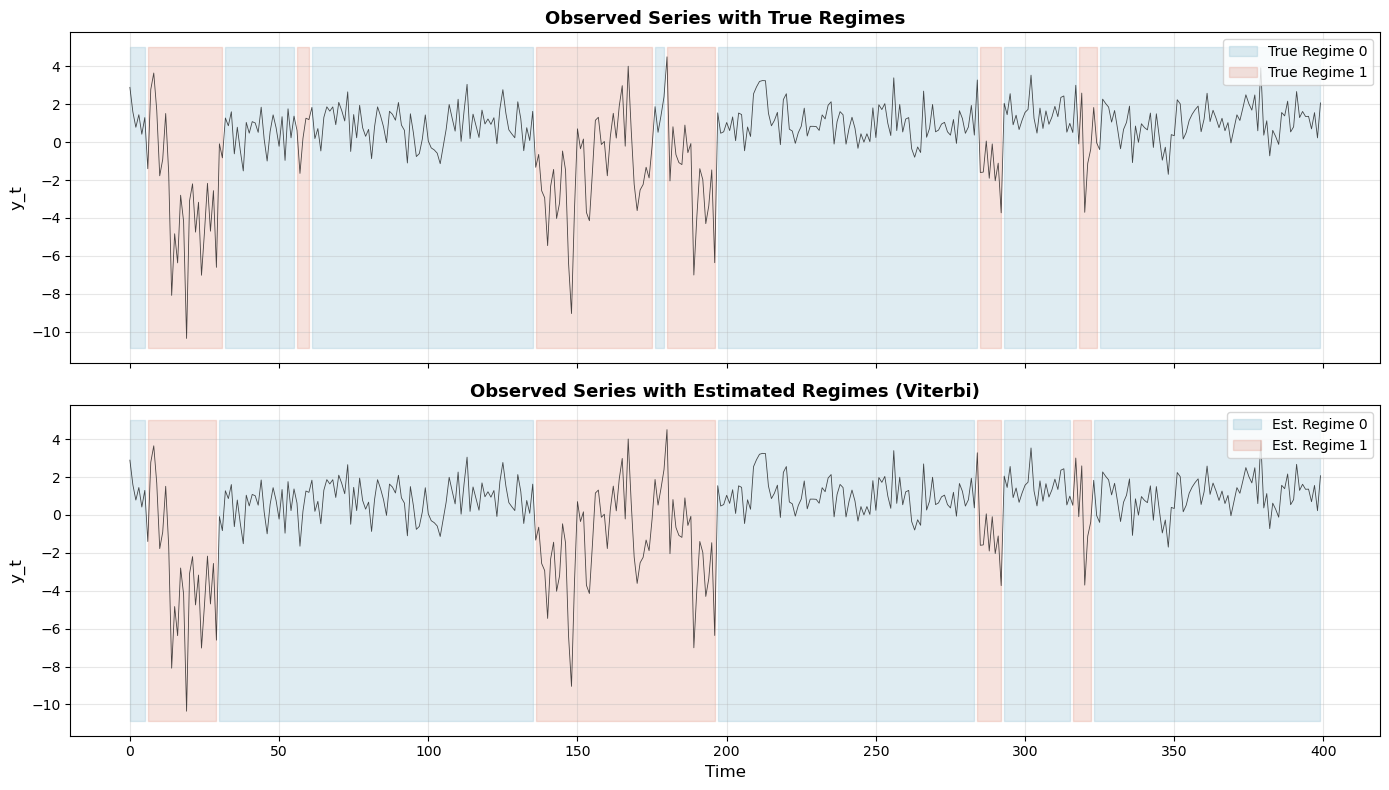

In [64]:
# ============================================
# Time Series with Regimes
# ============================================

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Top: True regimes
ax = axes[0]
ax.fill_between(time, y.min() - 0.5, y.max() + 0.5, 
                where=(states_true == 0), color='#2E86AB', alpha=0.15, label='True Regime 0')
ax.fill_between(time, y.min() - 0.5, y.max() + 0.5, 
                where=(states_true == 1), color='#C73E1D', alpha=0.15, label='True Regime 1')
ax.plot(time, y, '-', color='black', linewidth=0.6, alpha=0.7)
ax.set_ylabel('y_t', fontsize=12)
ax.set_title('Observed Series with True Regimes', fontsize=13, fontweight='bold')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)

# Bottom: Estimated regimes
ax = axes[1]
ax.fill_between(time, y.min() - 0.5, y.max() + 0.5, 
                where=(states_viterbi == 0), color='#2E86AB', alpha=0.15, label='Est. Regime 0')
ax.fill_between(time, y.min() - 0.5, y.max() + 0.5, 
                where=(states_viterbi == 1), color='#C73E1D', alpha=0.15, label='Est. Regime 1')
ax.plot(time, y, '-', color='black', linewidth=0.6, alpha=0.7)
ax.set_xlabel('Time', fontsize=12)
ax.set_ylabel('y_t', fontsize=12)
ax.set_title('Observed Series with Estimated Regimes (Viterbi)', fontsize=13, fontweight='bold')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Regime-Specific Regressions

A scatter plot of $y_t$ vs $x_t$ colored by regime reveals the distinct relationships in each state. The fitted regression lines show how the slope and intercept differ across regimes.

**What to look for:**
- Clear separation between regime clouds = good identifiability
- Regression lines with different slopes = regime-dependent effects
- Overlap in the middle = ambiguous observations near the boundary

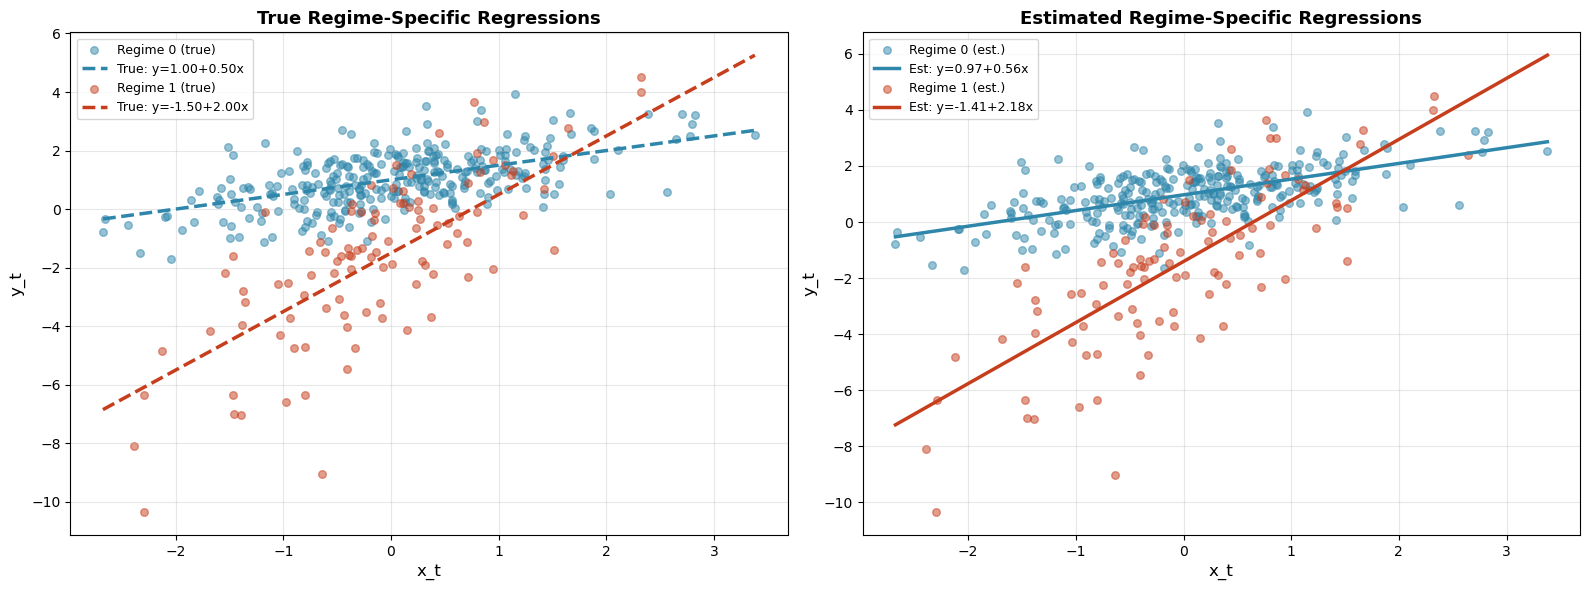

In [65]:
# ============================================
# Scatter Plot with Regime Regression Lines
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: True regimes
ax = axes[0]
for k, color, label in zip([0, 1], ['#2E86AB', '#C73E1D'], ['Regime 0', 'Regime 1']):
    mask = states_true == k
    ax.scatter(x[mask], y[mask], c=color, alpha=0.5, s=30, label=f'{label} (true)')
    x_line = np.linspace(x.min(), x.max(), 100)
    y_line = alpha_true[k] + beta_true[k] * x_line
    ax.plot(x_line, y_line, '--', color=color, linewidth=2.5,
            label=f'True: y={alpha_true[k]:.2f}+{beta_true[k]:.2f}x')

ax.set_xlabel('x_t', fontsize=12)
ax.set_ylabel('y_t', fontsize=12)
ax.set_title('True Regime-Specific Regressions', fontsize=13, fontweight='bold')
ax.legend(loc='best', fontsize=9)
ax.grid(True, alpha=0.3)

# Right: Estimated regimes
ax = axes[1]
for k, color, label in zip([0, 1], ['#2E86AB', '#C73E1D'], ['Regime 0', 'Regime 1']):
    mask = states_viterbi == k
    ax.scatter(x[mask], y[mask], c=color, alpha=0.5, s=30, label=f'{label} (est.)')
    x_line = np.linspace(x.min(), x.max(), 100)
    y_line = msr.alphas[k] + msr.betas[k] * x_line
    ax.plot(x_line, y_line, '-', color=color, linewidth=2.5,
            label=f'Est: y={msr.alphas[k]:.2f}+{msr.betas[k]:.2f}x')

ax.set_xlabel('x_t', fontsize=12)
ax.set_ylabel('y_t', fontsize=12)
ax.set_title('Estimated Regime-Specific Regressions', fontsize=13, fontweight='bold')
ax.legend(loc='best', fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Smoothed State Probabilities

The **Hamilton Filter** (Forward pass) computes $P(s_t \mid y_{1:t})$ using only past and current data. The **Kim Smoother** (Forward-Backward) computes $P(s_t \mid y_{1:T})$ using the full sample.

**Key insight:** Smoothed probabilities are generally more confident (closer to 0 or 1) because they incorporate future information. The filtered probabilities can be noisy at regime switches.


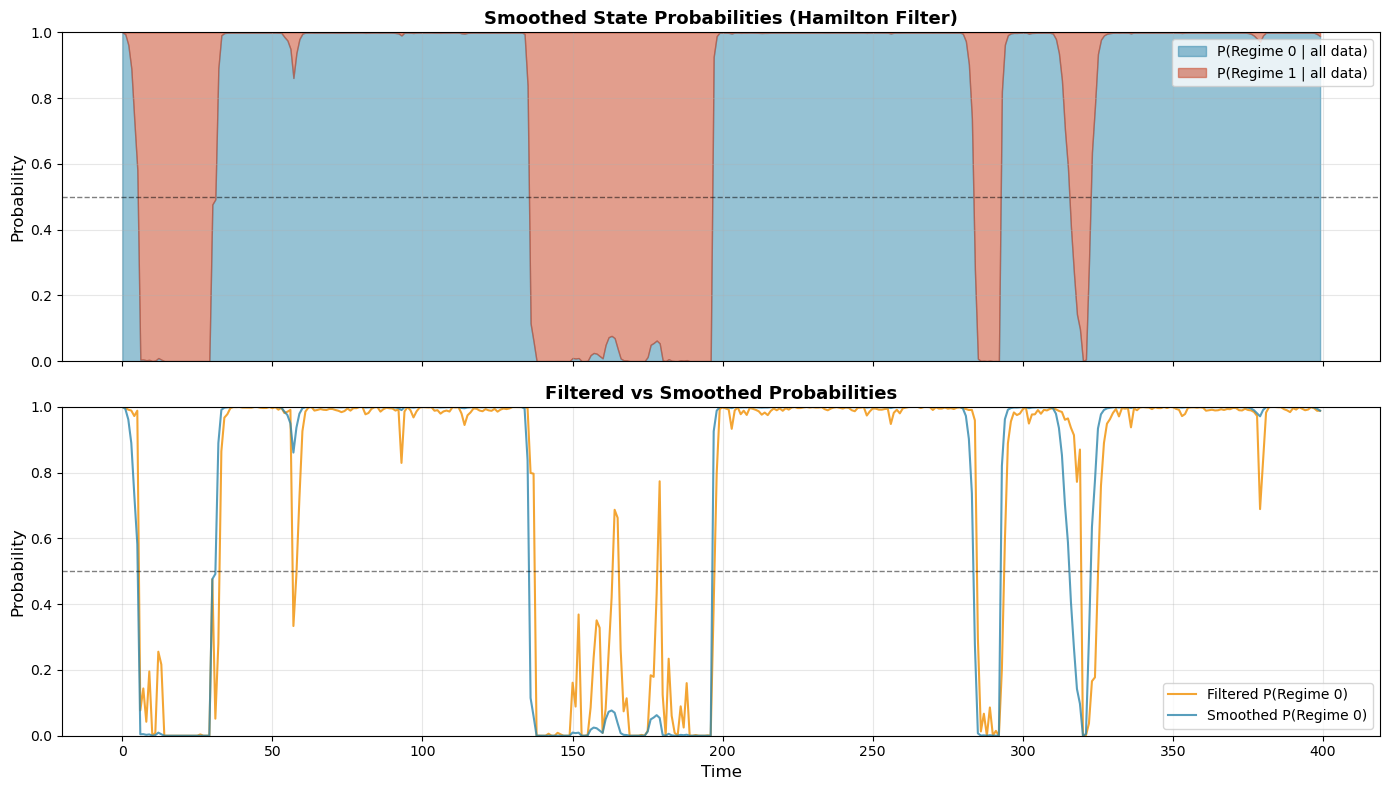

In [66]:
# ============================================
# Smoothed State Probabilities
# ============================================

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Top: Stacked probability area
ax = axes[0]
ax.fill_between(time, 0, gamma[:, 0], color='#2E86AB', alpha=0.5, label='P(Regime 0 | all data)')
ax.fill_between(time, gamma[:, 0], 1, color='#C73E1D', alpha=0.5, label='P(Regime 1 | all data)')
ax.axhline(y=0.5, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax.set_ylabel('Probability', fontsize=12)
ax.set_title('Smoothed State Probabilities (Hamilton Filter)', fontsize=13, fontweight='bold')
ax.set_ylim(0, 1)
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)

# Bottom: Filtered vs Smoothed
ax = axes[1]
alpha_fwd, _ = msr.forward(y, x, msr.pi, msr.A, msr.alphas, msr.betas, msr.sigmas)
ax.plot(time, alpha_fwd[:, 0], '-', color='#F18F01', linewidth=1.5, alpha=0.8, label='Filtered P(Regime 0)')
ax.plot(time, gamma[:, 0], '-', color='#2E86AB', linewidth=1.5, alpha=0.8, label='Smoothed P(Regime 0)')
ax.axhline(y=0.5, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax.set_xlabel('Time', fontsize=12)
ax.set_ylabel('Probability', fontsize=12)
ax.set_title('Filtered vs Smoothed Probabilities', fontsize=13, fontweight='bold')
ax.set_ylim(0, 1)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Transition Matrix & EM Convergence

**Left:** The true transition matrix vs. the EM-estimated matrix. High diagonal values indicate **persistent regimes** (long spells in each state).

**Right:** The Baum-Welch EM algorithm maximizes the log-likelihood iteratively. Fast, monotonic convergence indicates a well-specified model.


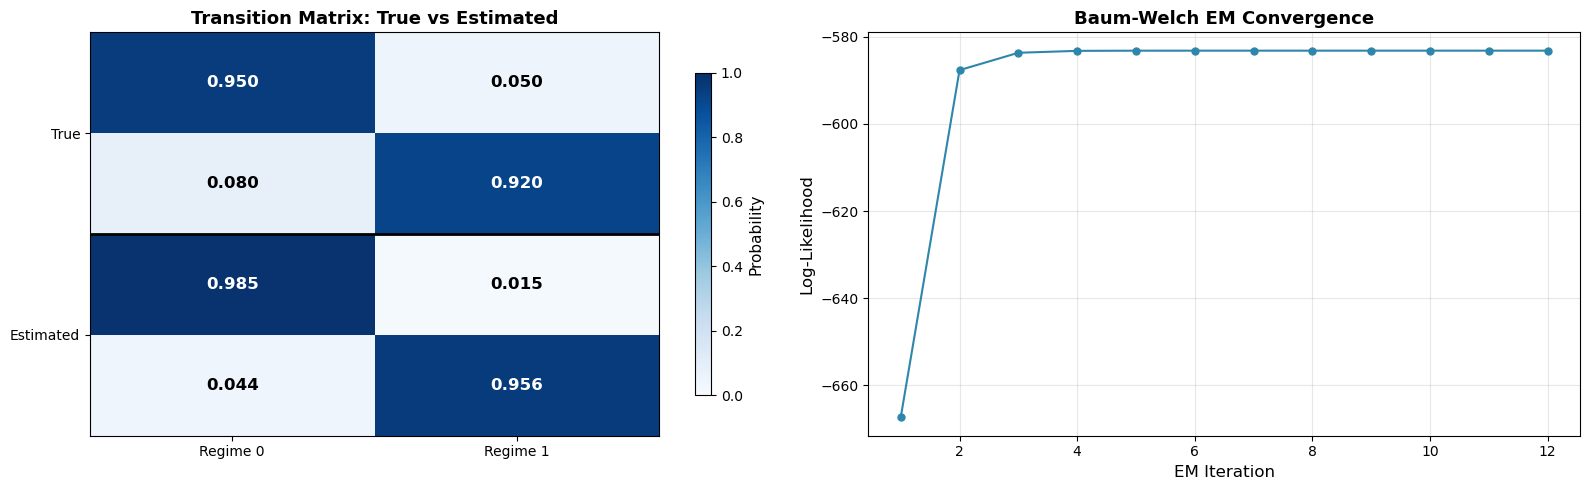

In [67]:
# ============================================
# Transition Matrix + EM Convergence
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: Transition matrices
ax = axes[0]
n = msr.n_regimes
combined = np.zeros((n * 2, n))
combined[:n, :] = transition_true
combined[n:, :] = msr.A

im = ax.imshow(combined, cmap='Blues', vmin=0, vmax=1, aspect='auto')
for i in range(n * 2):
    for j in range(n):
        val = combined[i, j]
        text_color = 'white' if val > 0.5 else 'black'
        ax.text(j, i, f'{val:.3f}', ha='center', va='center',
                color=text_color, fontsize=12, fontweight='bold')

ax.set_xticks(range(n))
ax.set_xticklabels(['Regime 0', 'Regime 1'])
ax.set_yticks([0.5, 2.5])
ax.set_yticklabels(['True', 'Estimated'])
ax.set_title('Transition Matrix: True vs Estimated', fontsize=13, fontweight='bold')
ax.axhline(y=1.5, color='black', linewidth=2)
cbar = plt.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label('Probability', fontsize=11)

# Right: EM convergence
ax = axes[1]
ax.plot(range(1, len(log_likes) + 1), log_likes, '-o', color='#2E86AB',
        markersize=5, linewidth=1.5)
ax.set_xlabel('EM Iteration', fontsize=12)
ax.set_ylabel('Log-Likelihood', fontsize=12)
ax.set_title('Baum-Welch EM Convergence', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Residual Diagnostics by Regime

Residuals are computed as $e_t = y_t - (\hat{\alpha}_{s_t} + \hat{\beta}_{s_t} x_t)$ using the Viterbi-assigned regime. They should be approximately Gaussian within each regime if the model is well-specified.


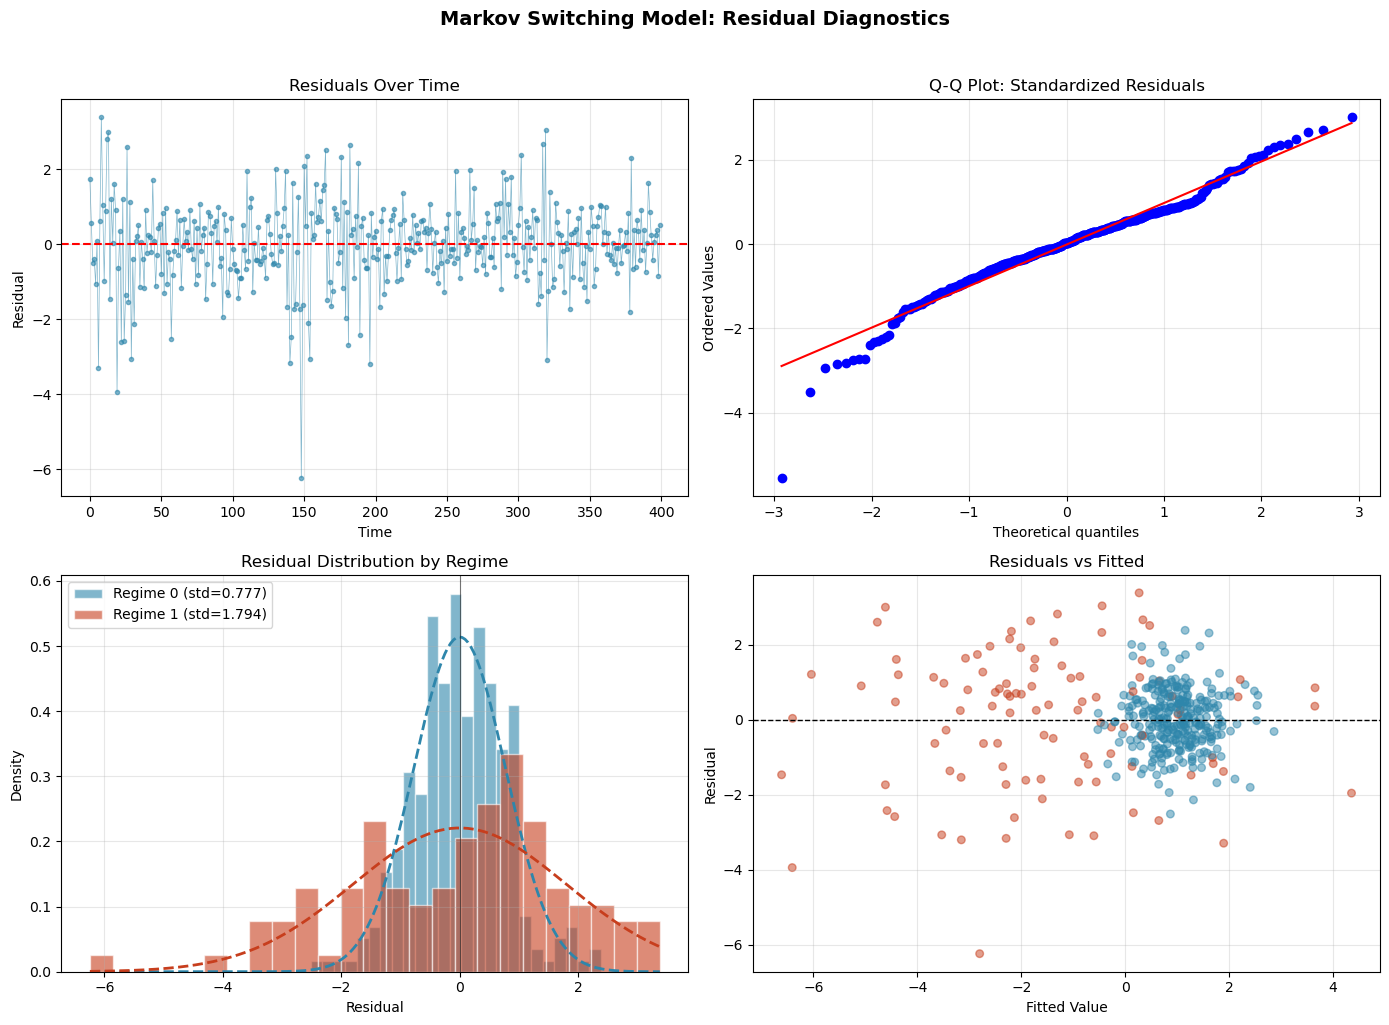

In [68]:
# ============================================
# Residual Diagnostics by Regime
# ============================================

resid = np.zeros(T)
for t in range(T):
    resid[t] = y[t] - (msr.alphas[states_viterbi[t]] + 
                       msr.betas[states_viterbi[t]] * x[t])

resid0 = resid[states_viterbi == 0]
resid1 = resid[states_viterbi == 1]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Residuals over time
ax = axes[0, 0]
ax.plot(time, resid, 'o-', color='#2E86AB', markersize=3, linewidth=0.5, alpha=0.6)
ax.axhline(y=0, color='red', linestyle='--', linewidth=1.5)
ax.set_xlabel('Time')
ax.set_ylabel('Residual')
ax.set_title('Residuals Over Time')
ax.grid(True, alpha=0.3)

# 2. Q-Q plot
ax = axes[0, 1]
std_resid = resid / np.std(resid)
stats.probplot(std_resid, dist="norm", plot=ax)
ax.set_title('Q-Q Plot: Standardized Residuals')
ax.grid(True, alpha=0.3)

# 3. Histogram by regime
ax = axes[1, 0]
ax.hist(resid0, bins=25, color='#2E86AB', alpha=0.6, edgecolor='white',
        density=True, label=f'Regime 0 (std={np.std(resid0):.3f})')
ax.hist(resid1, bins=25, color='#C73E1D', alpha=0.6, edgecolor='white',
        density=True, label=f'Regime 1 (std={np.std(resid1):.3f})')

x_range = np.linspace(resid.min(), resid.max(), 200)
ax.plot(x_range, stats.norm.pdf(x_range, 0, msr.sigmas[0]), '--', color='#2E86AB', linewidth=2)
ax.plot(x_range, stats.norm.pdf(x_range, 0, msr.sigmas[1]), '--', color='#C73E1D', linewidth=2)

ax.axvline(x=0, color='black', linestyle='-', linewidth=0.8, alpha=0.5)
ax.set_xlabel('Residual')
ax.set_ylabel('Density')
ax.set_title('Residual Distribution by Regime')
ax.legend()
ax.grid(True, alpha=0.3)

# 4. Residuals vs Fitted
ax = axes[1, 1]
fitted = y - resid
colors = ['#2E86AB' if s == 0 else '#C73E1D' for s in states_viterbi]
ax.scatter(fitted, resid, c=colors, alpha=0.5, s=30)
ax.axhline(y=0, color='black', linestyle='--', linewidth=1)
ax.set_xlabel('Fitted Value')
ax.set_ylabel('Residual')
ax.set_title('Residuals vs Fitted')
ax.grid(True, alpha=0.3)

plt.suptitle('Markov Switching Model: Residual Diagnostics', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


## Markov Switching Dashboard

A consolidated view combining all key diagnostics into one figure.


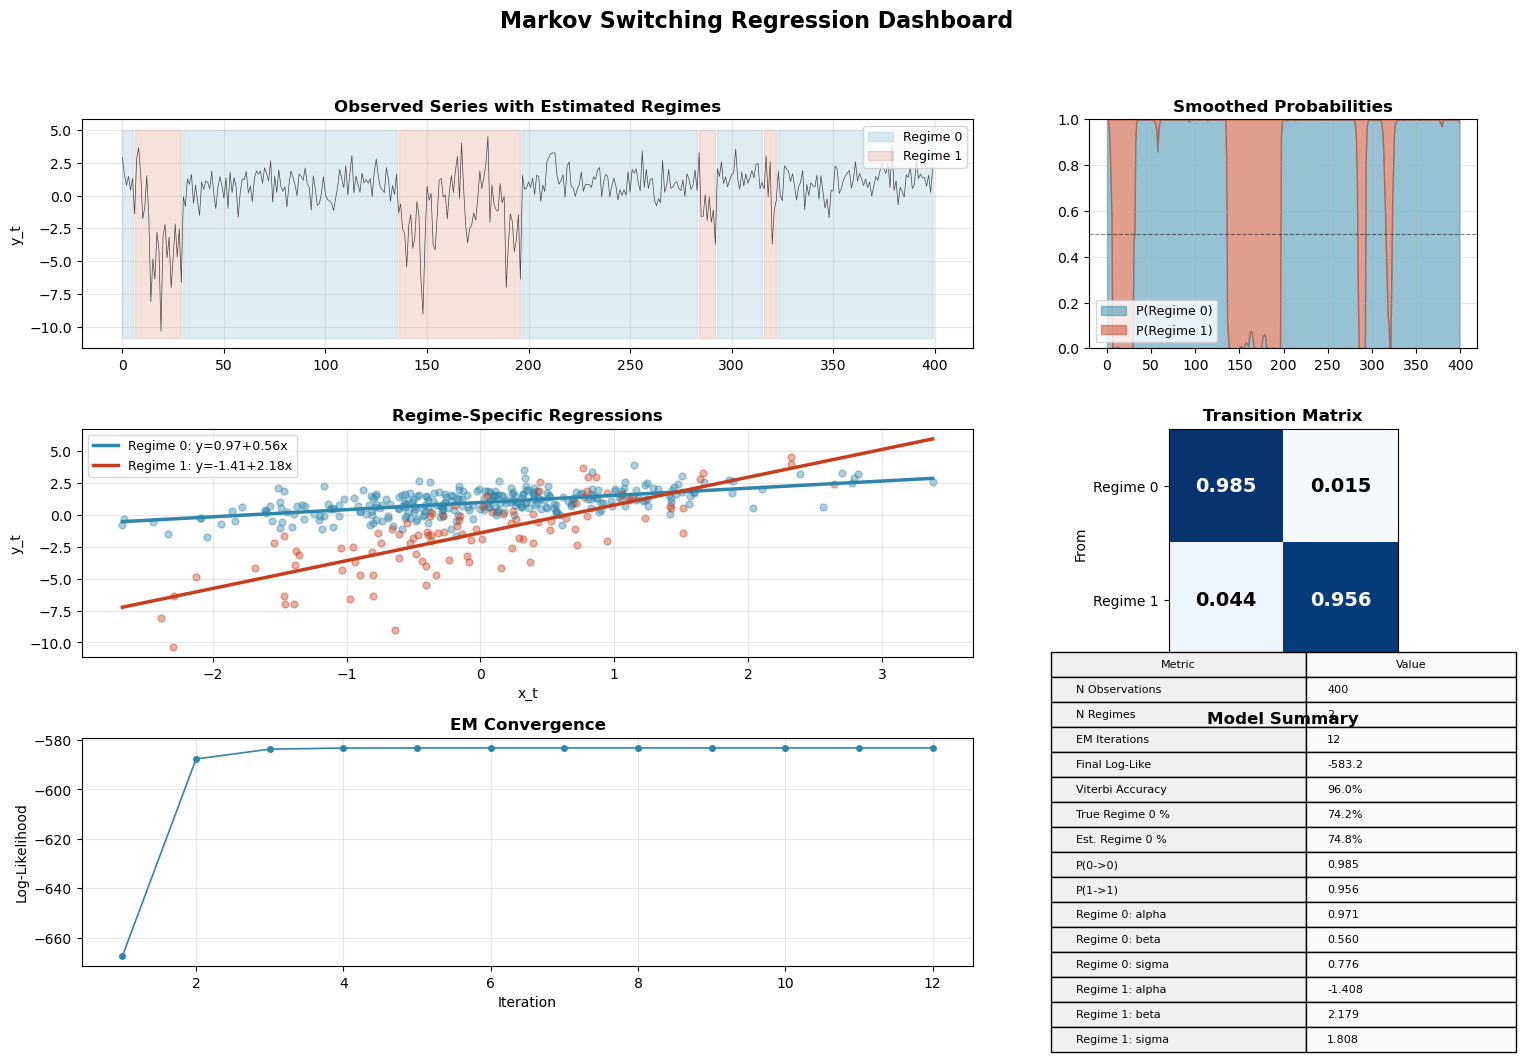

In [70]:
# ============================================
# Dashboard
# ============================================

fig = plt.figure(figsize=(18, 11))
gs = fig.add_gridspec(3, 3, hspace=0.35, wspace=0.3)

# Time Series with Regimes
ax1 = fig.add_subplot(gs[0, :2])
ax1.fill_between(time, y.min() - 0.5, y.max() + 0.5,
                 where=(states_viterbi == 0), color='#2E86AB', alpha=0.15, label='Regime 0')
ax1.fill_between(time, y.min() - 0.5, y.max() + 0.5,
                 where=(states_viterbi == 1), color='#C73E1D', alpha=0.15, label='Regime 1')
ax1.plot(time, y, '-', color='black', linewidth=0.5, alpha=0.7)
ax1.set_title('Observed Series with Estimated Regimes', fontsize=12, fontweight='bold')
ax1.set_ylabel('y_t')
ax1.legend(loc='upper right', fontsize=9)
ax1.grid(True, alpha=0.3)

# Smoothed Probabilities
ax2 = fig.add_subplot(gs[0, 2])
ax2.fill_between(time, 0, gamma[:, 0], color='#2E86AB', alpha=0.5, label='P(Regime 0)')
ax2.fill_between(time, gamma[:, 0], 1, color='#C73E1D', alpha=0.5, label='P(Regime 1)')
ax2.axhline(y=0.5, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
ax2.set_title('Smoothed Probabilities', fontsize=12, fontweight='bold')
ax2.set_ylim(0, 1)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

# Scatter with Regression Lines
ax3 = fig.add_subplot(gs[1, :2])
for k, color, label in zip([0, 1], ['#2E86AB', '#C73E1D'], ['Regime 0', 'Regime 1']):
    mask = states_viterbi == k
    ax3.scatter(x[mask], y[mask], c=color, alpha=0.4, s=25)
    x_line = np.linspace(x.min(), x.max(), 100)
    y_line = msr.alphas[k] + msr.betas[k] * x_line
    ax3.plot(x_line, y_line, '-', color=color, linewidth=2.5,
             label=f'{label}: y={msr.alphas[k]:.2f}+{msr.betas[k]:.2f}x')
ax3.set_title('Regime-Specific Regressions', fontsize=12, fontweight='bold')
ax3.set_xlabel('x_t')
ax3.set_ylabel('y_t')
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.3)

# Transition Matrix
ax4 = fig.add_subplot(gs[1, 2])
im = ax4.imshow(msr.A, cmap='Blues', vmin=0, vmax=1)
for i in range(2):
    for j in range(2):
        ax4.text(j, i, f'{msr.A[i,j]:.3f}', ha='center', va='center',
                color='white' if msr.A[i,j] > 0.5 else 'black', 
                fontsize=14, fontweight='bold')
ax4.set_xticks([0, 1])
ax4.set_xticklabels(['Regime 0', 'Regime 1'])
ax4.set_yticks([0, 1])
ax4.set_yticklabels(['Regime 0', 'Regime 1'])
ax4.set_title('Transition Matrix', fontsize=12, fontweight='bold')
ax4.set_xlabel('To')
ax4.set_ylabel('From')

# EM Convergence
ax5 = fig.add_subplot(gs[2, :2])
ax5.plot(range(1, len(log_likes) + 1), log_likes, '-o', color='#2E86AB',
         markersize=4, linewidth=1.2)
ax5.set_title('EM Convergence', fontsize=12, fontweight='bold')
ax5.set_xlabel('Iteration')
ax5.set_ylabel('Log-Likelihood')
ax5.grid(True, alpha=0.3)

# Metrics Table
ax6 = fig.add_subplot(gs[2, 2])
ax6.axis('off')

accuracy = np.mean(states_viterbi == states_true)

metrics = [
    ['N Observations', f'{T}'],
    ['N Regimes', f'{msr.n_regimes}'],
    ['EM Iterations', f'{len(log_likes)}'],
    ['Final Log-Like', f'{log_likes[-1]:.1f}'],
    ['Viterbi Accuracy', f'{accuracy:.1%}'],
    ['True Regime 0 %', f'{(states_true == 0).mean():.1%}'],
    ['Est. Regime 0 %', f'{(states_viterbi == 0).mean():.1%}'],
    ['P(0->0)', f'{msr.A[0,0]:.3f}'],
    ['P(1->1)', f'{msr.A[1,1]:.3f}'],
    ['Regime 0: alpha', f'{msr.alphas[0]:.3f}'],
    ['Regime 0: beta', f'{msr.betas[0]:.3f}'],
    ['Regime 0: sigma', f'{msr.sigmas[0]:.3f}'],
    ['Regime 1: alpha', f'{msr.alphas[1]:.3f}'],
    ['Regime 1: beta', f'{msr.betas[1]:.3f}'],
    ['Regime 1: sigma', f'{msr.sigmas[1]:.3f}'],
]

table = ax6.table(cellText=metrics, colLabels=['Metric', 'Value'],
                  cellLoc='left', loc='center', colWidths=[0.55, 0.45])
table.auto_set_font_size(False)
table.set_fontsize(8)
table.scale(1.2, 1.5)
for i in range(len(metrics) + 1):
    table[(i, 0)].set_facecolor('#f0f0f0')
    table[(i, 1)].set_facecolor('#fafafa')
ax6.set_title('Model Summary', fontsize=12, fontweight='bold', pad=10)

plt.suptitle('Markov Switching Regression Dashboard', 
             fontsize=16, fontweight='bold', y=0.98)
plt.show()


## Summary: How to Interpret Results

| Diagnostic | Good Sign | Bad Sign |
|------------|-----------|----------|
| **Viterbi Accuracy** | > 80% | < 60% (regimes not identifiable) |
| **Transition Diagonal** | High (~0.9+) = persistent regimes | Low (~0.5) = no regime structure |
| **Regression Separation** | Different slopes/intercepts | Nearly identical = redundant regimes |
| **EM Convergence** | Smooth, monotonic | Oscillations or early plateau |
| **Residuals** | Gaussian within each regime | Skewed or heteroscedastic |
| **Smoothed Probabilities** | Sharp 0/1 transitions | Always near 0.5 = uncertainty |

## Extensions

| Model | Use Case |
|-------|---------|
| **MS-AR** | Regime-dependent autoregressive coefficients |
| **MS-GARCH** | Regime-dependent volatility dynamics |
| **MS-VAR** | Vector autoregression with regime switching |
| **Time-Varying Transition** | Transition probabilities depend on covariates |
| **Bayesian MSM** | MCMC for parameter uncertainty |


In [71]:
# ============================================
# Final Summary
# ============================================

print("=" * 65)
print("MARKOV SWITCHING REGRESSION SUMMARY")
print("=" * 65)
print(f"{'Observations:':<35} {T}")
print(f"{'Regimes:':<35} {msr.n_regimes}")
print(f"{'EM Iterations:':<35} {len(log_likes)}")
print(f"{'Final Log-Likelihood:':<35} {log_likes[-1]:.2f}")
print(f"{'Viterbi Accuracy:':<35} {accuracy:.1%}")
print()
print("TRUE PARAMETERS:")
print(f"  Transition:  [[{transition_true[0,0]:.3f}, {transition_true[0,1]:.3f}],")
print(f"               [{transition_true[1,0]:.3f}, {transition_true[1,1]:.3f}]]")
print(f"  Regime 0:  alpha={alpha_true[0]:.3f}, beta={beta_true[0]:.3f}, sigma={sigma_true[0]:.3f}")
print(f"  Regime 1:  alpha={alpha_true[1]:.3f}, beta={beta_true[1]:.3f}, sigma={sigma_true[1]:.3f}")
print()
print("ESTIMATED PARAMETERS:")
print(f"  Transition:  [[{msr.A[0,0]:.3f}, {msr.A[0,1]:.3f}],")
print(f"               [{msr.A[1,0]:.3f}, {msr.A[1,1]:.3f}]]")
for k in range(2):
    print(f"  Regime {k}:  alpha={msr.alphas[k]:.3f}, beta={msr.betas[k]:.3f}, sigma={msr.sigmas[k]:.3f}")
print("=" * 65)


MARKOV SWITCHING REGRESSION SUMMARY
Observations:                       400
Regimes:                            2
EM Iterations:                      12
Final Log-Likelihood:               -583.20
Viterbi Accuracy:                   96.0%

TRUE PARAMETERS:
  Transition:  [[0.950, 0.050],
               [0.080, 0.920]]
  Regime 0:  alpha=1.000, beta=0.500, sigma=0.800
  Regime 1:  alpha=-1.500, beta=2.000, sigma=1.800

ESTIMATED PARAMETERS:
  Transition:  [[0.985, 0.015],
               [0.044, 0.956]]
  Regime 0:  alpha=0.971, beta=0.560, sigma=0.776
  Regime 1:  alpha=-1.408, beta=2.179, sigma=1.808
